# Paper Analysis Notebook

This notebook reproduces every quantitative result, table, and figure referenced in the paper.
It covers:

| Section | Analysis |
|---------|----------|
| Reliability | Cronbach α for SPMA and NASA-TLX composites |
| RQ1 | Authenticity composite – descriptives, RM-ANOVA, planned contrasts |
| RQ2 | Cognitive effort (NASA-TLX) – descriptives, RM-ANOVA, planned contrasts |
| RQ3a | Willingness to send – descriptives, RM-ANOVA |
| RQ3b | Task completion time – descriptives, RM-ANOVA + Friedman sensitivity check |
| RQ3c | Overall preference ranking – frequency table + bar chart |
| Behavioral | Spearman correlations between process metrics and SPMA composite |
| Item-level | Exploratory per-item authenticity breakdown |

Data loading is modelled after `quantitative_analysis.ipynb`.

## 0 – Packages

In [55]:
import pkgutil, subprocess, sys

REQUIRED = ["pandas", "numpy", "scipy", "statsmodels", "pingouin", "matplotlib", "seaborn"]
missing = [p for p in REQUIRED if pkgutil.find_loader(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
print("All packages available.")

All packages available.


/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_97574/2175698438.py:4: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  missing = [p for p in REQUIRED if pkgutil.find_loader(p) is None]


## 1 – Imports and global constants

In [56]:
import json, math, re
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

# ── Display options ──────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

# Publication-style theme: clean white grid, slightly larger font
sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)
PALETTE = {"thought_partner": "#4C72B0", "editor": "#55A868", "ghost_writer": "#C44E52"}

# ── Ordered condition constants (used throughout for consistent axis ordering) ─
CONDITION_ORDER  = ["thought_partner", "editor", "ghost_writer"]
CONDITION_LABELS = {"thought_partner": "Thought Partner",
                    "editor": "Editor",
                    "ghost_writer": "Ghost-writer"}

# ── Scale item names as they appear in the survey CSV ────────────────────────
AUTHENTICITY_ITEMS = [
    "sender_authenticity_genuine_thoughts_feelings",
    "sender_authenticity_authentic_voice",
    "sender_authenticity_stand_behind_message",
]
EFFORT_ITEMS = ["effort_mental_demand", "effort_effort", "effort_frustration"]

NUMERIC_TRIAL_COLS = AUTHENTICITY_ITEMS + EFFORT_ITEMS + [
    "satisfaction_willing_to_send",
    "manip_ai_helped_what_to_say",
]

PROCEDURAL_JSON_COLS = [
    "editor_ai_suggestions_json",
    "thought_partner_ai_questions_json",
    "thought_partner_human_responses_json",
]

# Label maps: translate free-text survey answers to canonical condition names
PREFERENCE_LABEL_MAP = {
    "AI asked reflection questions before you wrote": "thought_partner",
    "Workflow A: AI asked reflective questions, then you wrote independently": "thought_partner",
    "You wrote first, then reviewed AI revision suggestions": "editor",
    "Workflow B: You wrote first, then reviewed AI revision suggestions": "editor",
    "AI generated a draft from your bullet points": "ghost_writer",
    "Workflow C: You gave bullet points and AI generated one draft": "ghost_writer",
}

DATA_DATE = "2026-04-08"
TRIALS_PER_PARTICIPANT = 3

WORD_RE = re.compile(r"\b\w+\b")

print("Imports OK.")

Imports OK.


## 2 – Helper functions

All helpers are defined here so every subsequent cell is self-contained.

In [57]:
# ── Data I/O helpers ─────────────────────────────────────────────────────────

def resolve_data_dir() -> Path:
    """Look for the CSV exports in ./result_analysis or the current directory."""
    surveys_name = f"surveys_{DATA_DATE}.csv"
    procedural_name = f"procedural_{DATA_DATE}.csv"
    for candidate in [Path("result_analysis"), Path(".")]:
        if (candidate / surveys_name).exists() and (candidate / procedural_name).exists():
            return candidate
    raise FileNotFoundError("Could not locate survey CSV exports.")


def safe_json_loads(value):
    """Parse a JSON string; return the raw value if it is already parsed or unparseable."""
    if isinstance(value, (dict, list)):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.nan
    stripped = str(value).strip()
    if not stripped:
        return np.nan
    try:
        return json.loads(stripped)
    except json.JSONDecodeError:
        return value


def expand_responses(df: pd.DataFrame) -> pd.DataFrame:
    """Explode the responses_json column into individual columns."""
    parsed = df["responses_json"].apply(lambda v: safe_json_loads(v) if isinstance(v, str) else v)
    expanded = pd.json_normalize(parsed)
    return pd.concat([df.drop(columns=["responses_json"]).reset_index(drop=True),
                      expanded.reset_index(drop=True)], axis=1)


# ── Statistical helpers ──────────────────────────────────────────────────────

def cronbach_alpha(df: pd.DataFrame) -> float:
    """
    Cronbach's α via the variance decomposition formula:
        α = k/(k-1) * (1 - Σ var_i / var_total)
    Requires at least 2 items and 2 complete observations.
    """
    clean = df.dropna().astype(float)
    k = clean.shape[1]
    if clean.shape[0] < 2 or k < 2:
        return np.nan
    item_vars   = clean.var(axis=0, ddof=1)
    total_var   = clean.sum(axis=1).var(ddof=1)
    if np.isclose(total_var, 0.0):
        return np.nan
    return float((k / (k - 1.0)) * (1.0 - item_vars.sum() / total_var))


def run_rm_anova(data: pd.DataFrame, dv: str) -> pd.DataFrame:
    """
    One-way repeated-measures ANOVA with 3 conditions.
    Returns a tidy table including partial η².
    """
    rm_data = data[["participant_label", "condition", dv]].dropna().copy()
    model   = AnovaRM(rm_data, depvar=dv, subject="participant_label", within=["condition"]).fit()
    tbl = model.anova_table.reset_index().rename(columns={
        "index": "effect", "F Value": "F",
        "Num DF": "df_num", "Den DF": "df_den", "Pr > F": "p_value"
    })
    # partial η² = (F × df_num) / (F × df_num + df_den)
    tbl["partial_eta_sq"] = (tbl["F"] * tbl["df_num"]) / (
        (tbl["F"] * tbl["df_num"]) + tbl["df_den"]
    )
    return tbl


def planned_contrast(series: pd.Series, label: str) -> dict:
    """
    One-sample t-test on paired *differences* (e.g. TP − GW).
    Returns estimate, 95% CI, t, df, p, and Cohen's d_z.
    """
    clean = series.dropna().astype(float)
    n     = len(clean)
    m     = clean.mean()
    sd    = clean.std(ddof=1) if n > 1 else np.nan
    t_stat, p_val = stats.ttest_1samp(clean, popmean=0.0)
    df    = n - 1
    ci_lo = m - stats.t.ppf(0.975, df) * (sd / math.sqrt(n)) if n > 1 else np.nan
    ci_hi = m + stats.t.ppf(0.975, df) * (sd / math.sqrt(n)) if n > 1 else np.nan
    dz    = m / sd if n > 1 and not np.isclose(sd, 0.0) else np.nan
    return {"contrast": label, "n": n, "estimate": m,
            "ci_low": ci_lo, "ci_high": ci_hi,
            "t": t_stat, "df": df, "p": p_val, "cohens_dz": dz}


def friedman_test(data: pd.DataFrame, dv: str) -> dict:
    """Friedman χ² (non-parametric RM alternative) for the three conditions."""
    wide = data.pivot(index="participant_label", columns="condition", values=dv).reindex(
        columns=CONDITION_ORDER).dropna()
    chi2, p = stats.friedmanchisquare(*(wide[c] for c in CONDITION_ORDER))
    return {"chi2": chi2, "df": 2, "p": p, "n": len(wide)}


def spearman_corr(x: pd.Series, y: pd.Series, label: str) -> dict:
    """Spearman ρ between two series, dropping rows where either is NaN."""
    combined = pd.concat([x.rename("x"), y.rename("y")], axis=1).dropna()
    n = len(combined)
    if n < 3:
        return {"metric": label, "n": n, "rho": np.nan, "p": np.nan}
    rho, p = stats.spearmanr(combined["x"], combined["y"])
    return {"metric": label, "n": n, "rho": float(rho), "p": float(p)}


# ── Derived-variable helpers ─────────────────────────────────────────────────

def revision_extent(before: str, after: str) -> float:
    """
    Text-dissimilarity between two strings: 1 − SequenceMatcher ratio.
    0 = unchanged, 1 = completely different.
    """
    if not isinstance(before, str) or not isinstance(after, str):
        return np.nan
    return 1.0 - SequenceMatcher(None, before, after).ratio()


def reflection_word_count(json_val) -> float:
    """Total word count across all thought-partner reflection responses."""
    parsed = safe_json_loads(json_val)
    if not isinstance(parsed, list):
        return np.nan
    return float(sum(len(WORD_RE.findall(str(item.get("response", "")))) for item in parsed
                     if isinstance(item, dict)))


# ── Plotting helpers ─────────────────────────────────────────────────────────

def descriptives_by_condition(data: pd.DataFrame, dv: str) -> pd.DataFrame:
    """Mean, SD, median, min, max per condition."""
    tbl = (data.groupby("condition", observed=True)[dv]
              .agg(n="count", mean="mean", sd="std", median="median",
                   min="min", max="max")
              .reindex(CONDITION_ORDER).reset_index())
    tbl.insert(1, "label", tbl["condition"].map(CONDITION_LABELS))
    return tbl


def spaghetti_plot(data: pd.DataFrame, dv: str, title: str, ylabel: str,
                   ylim=(1, 7.3), yticks=None, sig_pairs=None, ax=None):
    """
    Spaghetti (individual trajectory) plot with group mean ± SEM overlay.

    sig_pairs: list of (cond_a, cond_b, p_label) tuples for significance brackets.
    """
    wide = data.pivot(index="participant_label", columns="condition", values=dv
                      ).reindex(columns=CONDITION_ORDER)
    x    = np.arange(len(CONDITION_ORDER))

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Individual participant trajectories (light grey)
    for _, row in wide.iterrows():
        ax.plot(x, row.values, color="#aaaaaa", alpha=0.45, lw=1.2, zorder=1)
        ax.scatter(x, row.values, color="#aaaaaa", alpha=0.45, s=20, zorder=1)

    # Group mean ± SEM (colored by condition)
    summ = data.groupby("condition", observed=True)[dv].agg(["mean", "sem"]).reindex(CONDITION_ORDER)
    colors = [PALETTE[c] for c in CONDITION_ORDER]
    ax.plot(x, summ["mean"].values, color="#333333", lw=2.5, zorder=3)
    for xi, (cond, row) in enumerate(summ.iterrows()):
        ax.scatter(xi, row["mean"], color=PALETTE[cond], s=120, zorder=4)
        ax.errorbar(xi, row["mean"], yerr=row["sem"],
                    fmt="none", color=PALETTE[cond], capsize=6, lw=2, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(ylim)
    if yticks is not None:
        ax.set_yticks(yticks)

    # Optional significance brackets
    if sig_pairs:
        y_top = ylim[1] - 0.1 if ylim else ax.get_ylim()[1] - 0.1
        bracket_step = 0.3
        for i, (ca, cb, plabel) in enumerate(sig_pairs):
            xi_a = CONDITION_ORDER.index(ca)
            xi_b = CONDITION_ORDER.index(cb)
            yb   = y_top - i * bracket_step
            ax.plot([xi_a, xi_a, xi_b, xi_b], [yb - 0.1, yb, yb, yb - 0.1],
                    color="#333333", lw=1.2)
            ax.text((xi_a + xi_b) / 2, yb + 0.05, plabel, ha="center", va="bottom",
                    fontsize=11)

    if standalone:
        plt.tight_layout()
        return fig, ax


print("Helpers defined.")

Helpers defined.


## 3 – Load and prepare data

Exactly mirrors the existing notebook's data pipeline.

In [58]:
DATA_DIR       = resolve_data_dir()
surveys_raw    = pd.read_csv(DATA_DIR / f"surveys_{DATA_DATE}.csv")
procedural_raw = pd.read_csv(DATA_DIR / f"procedural_{DATA_DATE}.csv")

# Split by survey type
pre_raw  = surveys_raw[surveys_raw["survey_type"] == "pre_study"].copy()
per_raw  = surveys_raw[surveys_raw["survey_type"] == "per_condition"].copy()
post_raw = surveys_raw[surveys_raw["survey_type"] == "post_study"].copy()

# Expand the JSON response column into flat columns for each survey type
pre_df  = expand_responses(pre_raw)
per_df  = expand_responses(per_raw)
post_df = expand_responses(post_raw)

# Coerce trial_index to integer in both survey and procedural frames
for df in [per_df, procedural_raw]:
    df["trial_index"] = pd.to_numeric(df["trial_index"], errors="coerce").astype("Int64")

procedural_df = procedural_raw.copy()
procedural_df["order_position"] = pd.to_numeric(procedural_df["order_position"], errors="coerce").astype("Int64")

# Coerce all Likert / time columns to float so NaN propagation is clean
PROC_NUMERIC = [
    "completion_time_sec", "word_count", "keystroke_count", "self_authored_text_ratio",
    "suggestion_total_count", "suggestion_accept_count", "suggestion_modify_count",
    "suggestion_reject_count", "suggestion_applied_count",
    "suggestion_acceptance_rate", "suggestion_modify_rate", "suggestion_applied_rate",
    "ghost_writer_edit_count", "reflection_duration_sec",
]
for col in NUMERIC_TRIAL_COLS:
    per_df[col] = pd.to_numeric(per_df[col], errors="coerce")
for col in PROC_NUMERIC:
    procedural_df[col] = pd.to_numeric(procedural_df[col], errors="coerce")
for col in PROCEDURAL_JSON_COLS:
    procedural_df[col] = procedural_df[col].apply(safe_json_loads)

# Merge per-condition survey answers with procedural/behavioral log
MERGE_KEYS = ["session_id", "participant_id", "participant_label",
              "access_code", "trial_index", "condition", "scenario_id"]
trial_df = per_df.merge(procedural_df, on=MERGE_KEYS, how="left", validate="one_to_one")

# Attach pre-study covariates (one row per participant → fan out to 3 rows)
COVARIATE_COLS = ["session_id", "pre_age_group", "pre_gender",
                  "pre_prior_ai_usage_frequency", "pre_writing_confidence"]
trial_df = trial_df.merge(pre_df[[c for c in COVARIATE_COLS if c in pre_df.columns]],
                           on="session_id", how="left", validate="many_to_one")

# Set ordered categorical so groupby respects our preferred display order
trial_df["condition"] = pd.Categorical(trial_df["condition"], categories=CONDITION_ORDER, ordered=True)

# ── Compute composite scales ─────────────────────────────────────────────────
# Authenticity composite: mean of 3 SPMA items (7-pt Likert each)
trial_df["authenticity_composite"] = trial_df[AUTHENTICITY_ITEMS].mean(axis=1)

# Effort composite: mean of 3 NASA-TLX items (mental demand, effort, frustration)
trial_df["effort_composite"] = trial_df[EFFORT_ITEMS].mean(axis=1)

# ── Compute behavioral / process metrics ────────────────────────────────────
# Ghost-writer revision extent: how much the participant changed the AI draft
trial_df["ghost_revision_extent"] = trial_df.apply(
    lambda r: revision_extent(r["ghost_writer_ai_draft_text"], r["ghost_writer_post_message_text"])
              if r["condition"] == "ghost_writer" else np.nan, axis=1)

# Editor revision extent: how much the AI changed the participant's original draft
trial_df["editor_revision_extent"] = trial_df.apply(
    lambda r: revision_extent(r["editor_pre_message_text"], r["editor_post_message_text"])
              if r["condition"] == "editor" else np.nan, axis=1)

# Thought-partner reflection word count: how much the participant wrote in reflections
trial_df["tp_reflection_word_count"] = trial_df.apply(
    lambda r: reflection_word_count(r["thought_partner_human_responses_json"])
              if r["condition"] == "thought_partner" else np.nan, axis=1)

# Parse the post-study preference ranking list
post_df["overall_preference_ranking"] = post_df["overall_preference_ranking"].apply(safe_json_loads)

N_PARTICIPANTS = trial_df["participant_label"].nunique()
N_TRIALS = N_PARTICIPANTS * TRIALS_PER_PARTICIPANT

# Sanity checks
assert len(trial_df) == N_TRIALS, (
    f"Expected {N_TRIALS} rows ({N_PARTICIPANTS} participants × {TRIALS_PER_PARTICIPANT} conditions), got {len(trial_df)}"
)
assert trial_df["participant_label"].nunique() == N_PARTICIPANTS
assert trial_df.groupby("participant_label").size().eq(TRIALS_PER_PARTICIPANT).all()

display(Markdown("### Data loaded successfully"))
display(trial_df[["participant_label", "condition", "scenario_id",
                   "authenticity_composite", "effort_composite",
                   "completion_time_sec", "ghost_revision_extent",
                   "editor_revision_extent", "reflection_duration_sec"]].head(9))

### Data loaded successfully

,participant_label,condition,scenario_id,authenticity_composite,effort_composite,completion_time_sec,ghost_revision_extent,editor_revision_extent,reflection_duration_sec
0,P002,editor,scenario_a,6.667,6.000,432,NaN,0.070,NaN
1,P002,ghost_writer,scenario_b,6.667,6.000,494,0.969,NaN,NaN
2,P002,thought_partner,scenario_c,6.667,6.667,884,NaN,NaN,339.000
3,P006,ghost_writer,scenario_a,5.333,4.000,341,0.069,NaN,NaN
4,P006,thought_partner,scenario_b,7.000,6.000,957,NaN,NaN,138.000
5,P006,editor,scenario_c,7.000,6.333,375,NaN,0.192,NaN
6,P001,thought_partner,scenario_a,7.000,5.333,508,NaN,NaN,133.000
7,P001,editor,scenario_b,6.333,3.667,340,NaN,0.738,NaN
8,P001,ghost_writer,scenario_c,4.000,3.333,294,0.862,NaN,NaN


---
## 4 – Scale Reliability (Cronbach α)

Both composite scales must exceed the conventional .70 threshold before we proceed with composite-level analyses.

In [59]:
# ── Compute α for each scale ──────────────────────────────────────────────────
# We compute α globally across all trial rows (all participants × all conditions).
# This treats the three conditions as repeated measurement contexts for the same scale.

alpha_spma  = cronbach_alpha(trial_df[AUTHENTICITY_ITEMS])
alpha_effort = cronbach_alpha(trial_df[EFFORT_ITEMS])

reliability_df = pd.DataFrame([
    {"Scale": "SPMA (authenticity)",  "Items": " / ".join(AUTHENTICITY_ITEMS), "α": alpha_spma},
    {"Scale": "NASA-TLX short form",  "Items": " / ".join(EFFORT_ITEMS),       "α": alpha_effort},
])
display(Markdown("### Table: Cronbach α"))
display(reliability_df)

# Flag any scales below threshold
for _, row in reliability_df.iterrows():
    status = "✓ OK" if row["α"] >= 0.70 else "⚠ BELOW .70"
    print(f"{row['Scale']}: α = {row['α']:.2f}  {status}")

### Table: Cronbach α

,Scale,Items,α
0,SPMA (authenticity),sender_authenticity_genuine_thoughts_feelings ...,0.850
1,NASA-TLX short form,effort_mental_demand / effort_effort / effort_...,0.895


SPMA (authenticity): α = 0.85  ✓ OK
NASA-TLX short form: α = 0.90  ✓ OK


---
## 5 – RQ1: Sender-Perceived Authenticity (SPMA)

### 5.1 Descriptive statistics

In [60]:
# ── Descriptives table (mirrors Table 1 in the paper) ────────────────────────
auth_desc = descriptives_by_condition(trial_df, "authenticity_composite")
display(Markdown(f"### Table 1 – Authenticity composite descriptives by condition (*N* = {N_PARTICIPANTS})"))
display(auth_desc)

### Table 1 – Authenticity composite descriptives by condition (*N* = 21)

,condition,label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,21,6.302,0.649,6.333,4.667,7.000
1,editor,Editor,21,6.127,0.619,6.000,4.667,7.000
2,ghost_writer,Ghost-writer,21,4.952,1.404,5.000,2.333,7.000


### 5.2 Spaghetti plot

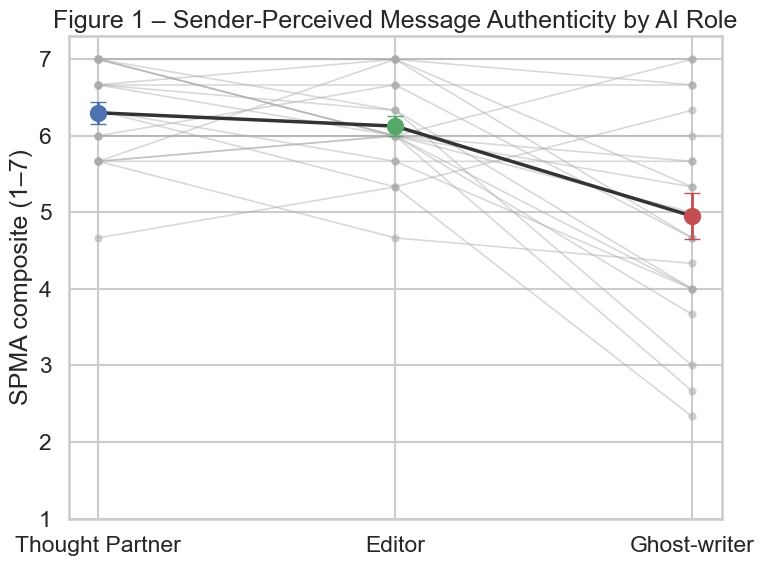

In [61]:
# ── Figure 1: Authenticity composite by condition ─────────────────────────────
# Spaghetti plot: grey lines = individual participants, colored dots = group mean ± SEM.
# Significance brackets are added after the ANOVA below; run this cell again to include them.

fig, ax = spaghetti_plot(
    trial_df, "authenticity_composite",
    title="Figure 1 – Sender-Perceived Message Authenticity by AI Role",
    ylabel="SPMA composite (1–7)",
    ylim=(1, 7.3),
    yticks=[1, 2, 3, 4, 5, 6, 7],
    # After running 5.3, replace None with the significant pairs, e.g.:
    # sig_pairs=[("thought_partner", "ghost_writer", "***"),
    #            ("editor", "ghost_writer", "**")]
    sig_pairs=None,
)
plt.savefig(DATA_DIR / "fig1_authenticity_spaghetti.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Repeated-measures ANOVA

In [62]:
# ── One-way RM ANOVA: authenticity composite ──────────────────────────────────
# Tests H1: at least one condition differs in felt authenticity.
# Uses AnovaRM from statsmodels (equivalent to the SPSS/JASP repeated-measures ANOVA).
# Degrees of freedom: between-conditions df = 2, within-error df = (21-1)*2 = 40.

anova_auth = run_rm_anova(trial_df, "authenticity_composite")
display(Markdown("### RM ANOVA – Authenticity composite"))
display(anova_auth)

### RM ANOVA – Authenticity composite

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,14.444,2.000,40.000,0.000,0.419


### 5.4 Pre-planned pairwise contrasts

In [63]:
# ── Planned contrasts: pair-wise differences on paired data ──────────────────
# We compute difference scores (Condition A − Condition B) for each participant
# and run a one-sample t-test against μ = 0.
# The two pre-registered contrasts are:
#   1. Thought Partner vs. Ghost-writer  (H1a)
#   2. Editor vs. Ghost-writer           (H1b)
# An exploratory contrast is:
#   3. Thought Partner vs. Editor        (are they equivalent?)

wide_auth = trial_df.pivot(index="participant_label", columns="condition",
                            values="authenticity_composite").reindex(columns=CONDITION_ORDER)

contrasts_auth = pd.DataFrame([
    planned_contrast(wide_auth["thought_partner"] - wide_auth["ghost_writer"],
                     "Thought Partner − Ghost-writer"),
    planned_contrast(wide_auth["editor"]          - wide_auth["ghost_writer"],
                     "Editor − Ghost-writer"),
    planned_contrast(wide_auth["thought_partner"] - wide_auth["editor"],
                     "Thought Partner − Editor  [exploratory]"),
])

display(Markdown("### Planned contrasts – Authenticity composite"))
display(contrasts_auth)

# ── Multiple-comparison correction across the two pre-planned contrasts ─────
# Holm controls family-wise error rate without being as conservative as Bonferroni.
# Bonferroni is included as a second adjusted p-value for reporting flexibility.
preplanned_p = contrasts_auth.loc[:1, "p"].values
reject_holm, p_adj_holm, _, _ = multipletests(preplanned_p, method="holm")
_, p_adj_bonf, _, _ = multipletests(preplanned_p, method="bonferroni")
contrasts_auth.loc[:1, "p_holm"] = p_adj_holm
contrasts_auth.loc[:1, "reject_holm"] = reject_holm
contrasts_auth.loc[:1, "p_bonferroni"] = p_adj_bonf
display(Markdown("**After Holm and Bonferroni correction (pre-planned only):**"))
display(contrasts_auth[["contrast", "estimate", "ci_low", "ci_high", "t", "df", "p", "p_holm", "p_bonferroni", "cohens_dz"]])

### Planned contrasts – Authenticity composite

,contrast,n,estimate,ci_low,ci_high,t,df,p,cohens_dz
0,Thought Partner − Ghost-writer,21,1.349,0.635,2.063,3.941,20,0.001,0.860
1,Editor − Ghost-writer,21,1.175,0.565,1.785,4.017,20,0.001,0.877
2,Thought Partner − Editor [exploratory],21,0.175,-0.127,0.477,1.206,20,0.242,0.263


**After Holm and Bonferroni correction (pre-planned only):**

,contrast,estimate,ci_low,ci_high,t,df,p,p_holm,p_bonferroni,cohens_dz
0,Thought Partner − Ghost-writer,1.349,0.635,2.063,3.941,20,0.001,0.001,0.002,0.860
1,Editor − Ghost-writer,1.175,0.565,1.785,4.017,20,0.001,0.001,0.001,0.877
2,Thought Partner − Editor [exploratory],0.175,-0.127,0.477,1.206,20,0.242,NaN,NaN,0.263


---
## 6 – RQ2: Cognitive Effort (NASA-TLX)

Expected pattern per H2: Editor > Thought Partner > Ghost-writer.

In [64]:
# ── 6.1 Descriptives ─────────────────────────────────────────────────────────
effort_desc = descriptives_by_condition(trial_df, "effort_composite")
display(Markdown(f"### Table – Cognitive effort composite descriptives (*N* = {N_PARTICIPANTS})"))
display(effort_desc)

### Table – Cognitive effort composite descriptives (*N* = 21)

,condition,label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,21,4.889,1.510,5.000,2.000,7.000
1,editor,Editor,21,4.190,1.405,4.333,2.000,6.333
2,ghost_writer,Ghost-writer,21,3.810,1.566,4.000,1.000,6.667


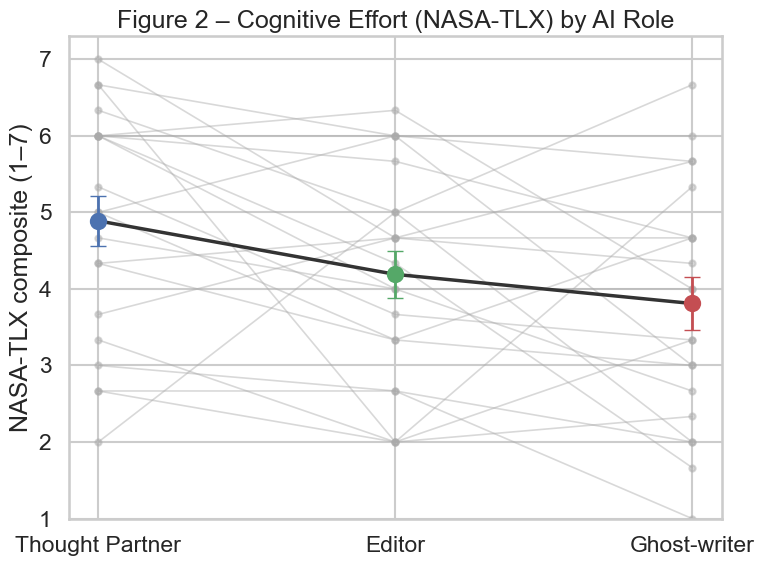

In [65]:
# ── 6.2 Spaghetti plot ───────────────────────────────────────────────────────
# Higher effort composite = more demanding / frustrating task.
fig2, ax2 = spaghetti_plot(
    trial_df, "effort_composite",
    title="Figure 2 – Cognitive Effort (NASA-TLX) by AI Role",
    ylabel="NASA-TLX composite (1–7)",
    ylim=(1, 7.3),
    yticks=[1, 2, 3, 4, 5, 6, 7],
)
plt.savefig(DATA_DIR / "fig2_effort_spaghetti.png", dpi=150, bbox_inches="tight")
plt.show()

In [66]:
# ── 6.3 RM ANOVA ─────────────────────────────────────────────────────────────
anova_effort = run_rm_anova(trial_df, "effort_composite")
display(Markdown("### RM ANOVA – Cognitive effort composite"))
display(anova_effort)

### RM ANOVA – Cognitive effort composite

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,5.808,2.000,40.000,0.006,0.225


In [67]:
# ── 6.4 Planned contrasts on effort ──────────────────────────────────────────
# H2a: Editor demands more effort than Ghost-writer
# H2b: Editor demands more effort than Thought Partner
# Exploratory: Thought Partner vs. Ghost-writer

wide_eff = trial_df.pivot(index="participant_label", columns="condition",
                           values="effort_composite").reindex(columns=CONDITION_ORDER)

contrasts_eff = pd.DataFrame([
    planned_contrast(wide_eff["editor"]          - wide_eff["ghost_writer"],
                     "Editor − Ghost-writer"),
    planned_contrast(wide_eff["editor"]          - wide_eff["thought_partner"],
                     "Editor − Thought Partner"),
    planned_contrast(wide_eff["thought_partner"] - wide_eff["ghost_writer"],
                     "Thought Partner − Ghost-writer  [exploratory]"),
])

# Apply Holm and Bonferroni correction to the two pre-planned effort contrasts
preplanned_eff_p = contrasts_eff.loc[:1, "p"].values
_, p_adj_eff, _, _ = multipletests(preplanned_eff_p, method="holm")
_, p_adj_eff_bonf, _, _ = multipletests(preplanned_eff_p, method="bonferroni")
contrasts_eff.loc[:1, "p_holm"] = p_adj_eff
contrasts_eff.loc[:1, "p_bonferroni"] = p_adj_eff_bonf

display(Markdown("### Planned contrasts – Cognitive effort"))
display(contrasts_eff)

### Planned contrasts – Cognitive effort

,contrast,n,estimate,ci_low,ci_high,t,df,p,cohens_dz,p_holm,p_bonferroni
0,Editor − Ghost-writer,21,0.381,-0.357,1.119,1.077,20,0.294,0.235,0.294,0.588
1,Editor − Thought Partner,21,-0.698,-1.394,-0.003,-2.096,20,0.049,-0.457,0.098,0.098
2,Thought Partner − Ghost-writer [exploratory],21,1.079,0.514,1.645,3.981,20,0.001,0.869,NaN,NaN


---
## 7 – RQ3a: Willingness to Send

In [68]:
# ── 7.1 Descriptives ─────────────────────────────────────────────────────────
# Single 7-pt Likert item: "I would be willing to send this message."
wts_desc = descriptives_by_condition(trial_df, "satisfaction_willing_to_send")
display(Markdown(f"### Table – Willingness to send descriptives (*N* = {N_PARTICIPANTS})"))
display(wts_desc)

### Table – Willingness to send descriptives (*N* = 21)

,condition,label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,21,5.810,1.209,6.000,3,7
1,editor,Editor,21,5.952,1.024,6.000,3,7
2,ghost_writer,Ghost-writer,21,4.381,1.830,4.000,1,7


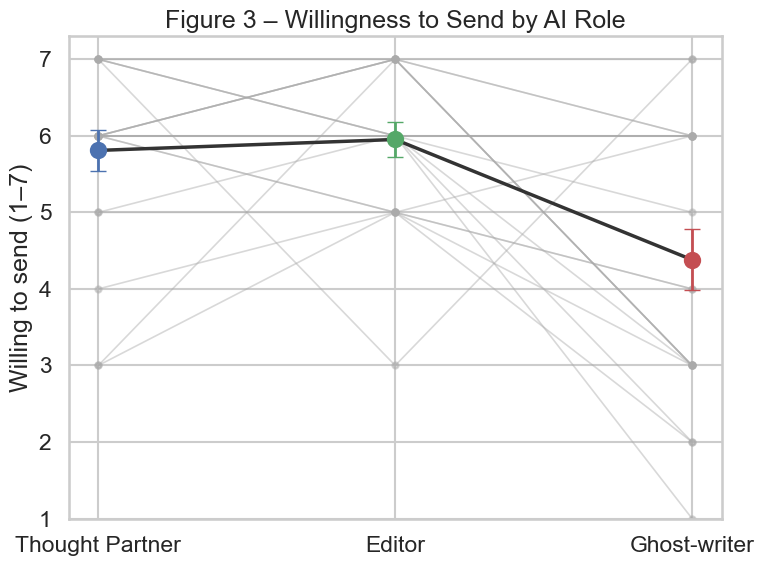

### RM ANOVA – Willingness to send

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,7.967,2.000,40.000,0.001,0.285


In [69]:
# ── 7.2 Spaghetti + RM ANOVA ─────────────────────────────────────────────────
fig3, ax3 = spaghetti_plot(
    trial_df, "satisfaction_willing_to_send",
    title="Figure 3 – Willingness to Send by AI Role",
    ylabel="Willing to send (1–7)",
    ylim=(1, 7.3),
    yticks=[1, 2, 3, 4, 5, 6, 7],
)
plt.savefig(DATA_DIR / "fig3_wts_spaghetti.png", dpi=150, bbox_inches="tight")
plt.show()

anova_wts = run_rm_anova(trial_df, "satisfaction_willing_to_send")
display(Markdown("### RM ANOVA – Willingness to send"))
display(anova_wts)

---
## 8 – RQ3b: Task Completion Time

In [70]:
# ── 8.1 Log-transform before RM ANOVA ────────────────────────────────────────
# Completion time distributions are typically right-skewed.
# We log-transform for the parametric RM ANOVA but also run a non-parametric
# Friedman test on raw seconds as a sensitivity check.

trial_df["log_completion_time"] = np.log(trial_df["completion_time_sec"].clip(lower=1))

time_desc = descriptives_by_condition(trial_df, "completion_time_sec")
display(Markdown(f"### Table – Completion time (seconds) descriptives (*N* = {N_PARTICIPANTS})"))
display(time_desc)

### Table – Completion time (seconds) descriptives (*N* = 21)

,condition,label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,21,969.762,525.232,884.000,374,2328
1,editor,Editor,21,585.381,341.626,433.000,193,1619
2,ghost_writer,Ghost-writer,21,404.619,237.462,341.000,174,1269


/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_97574/3738649172.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="label", y="completion_time_sec",


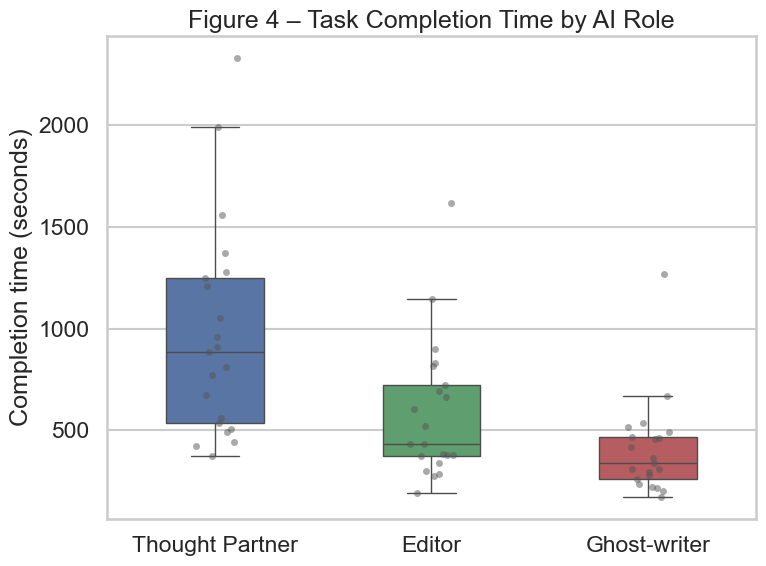

In [71]:
# ── 8.2 Box + strip plot (raw seconds) ───────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(8, 6))
# Strip plot shows all data points; box shows quartiles
plot_data = trial_df[["condition", "completion_time_sec"]].copy()
plot_data["label"] = plot_data["condition"].map(CONDITION_LABELS)
order_labels = [CONDITION_LABELS[c] for c in CONDITION_ORDER]
sns.boxplot(data=plot_data, x="label", y="completion_time_sec",
            order=order_labels, palette=PALETTE.values(),
            width=0.45, fliersize=0, ax=ax4)
sns.stripplot(data=plot_data, x="label", y="completion_time_sec",
              order=order_labels, color="#555555", alpha=0.5, size=5,
              jitter=True, ax=ax4)
ax4.set_title("Figure 4 – Task Completion Time by AI Role")
ax4.set_xlabel("")
ax4.set_ylabel("Completion time (seconds)")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig4_time_boxstrip.png", dpi=150, bbox_inches="tight")
plt.show()

In [72]:
# ── 8.3 RM ANOVA on log time + Friedman sensitivity check ────────────────────
anova_time = run_rm_anova(trial_df, "log_completion_time")
display(Markdown("### RM ANOVA – log(completion time)"))
display(anova_time)

friedman_time = friedman_test(trial_df, "completion_time_sec")
display(Markdown("### Friedman sensitivity check – raw completion time"))
display(pd.DataFrame([friedman_time]))

### RM ANOVA – log(completion time)

,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,29.886,2.000,40.000,0.000,0.599


### Friedman sensitivity check – raw completion time

,chi2,df,p,n
0,20.667,2,0.000,21


---
## 9 – RQ3c: Overall Preference Ranking

In [73]:
# ── Build long-form preference table ─────────────────────────────────────────
# Each participant ranked 3 conditions from most to least preferred.
# rank = 1 → most preferred.

pref_records = []
for _, row in post_df.iterrows():
    ranking = row.get("overall_preference_ranking", np.nan)
    if not isinstance(ranking, list):
        continue
    for rank, label in enumerate(ranking, start=1):
        cond = PREFERENCE_LABEL_MAP.get(label, np.nan)
        pref_records.append({"participant_label": row["participant_label"],
                              "rank": rank, "raw_label": label, "condition": cond})

pref_long = pd.DataFrame(pref_records)
pref_long["condition"] = pd.Categorical(pref_long["condition"],
                                         categories=CONDITION_ORDER, ordered=True)

# ── Frequency table: how many times each condition was ranked 1st, 2nd, 3rd ──
freq_table = (pref_long.groupby(["condition", "rank"], observed=True)
                         .size().unstack("rank", fill_value=0)
                         .reindex(CONDITION_ORDER)
                         .rename(columns={1: "1st", 2: "2nd", 3: "3rd"}))
freq_table.index = [CONDITION_LABELS[c] for c in freq_table.index]
display(Markdown(f"### Table – Overall preference ranking frequencies (*N* = {N_PARTICIPANTS})"))
display(freq_table)

### Table – Overall preference ranking frequencies (*N* = 21)

rank,1st,2nd,3rd
Thought Partner,2,10,9
Editor,14,5,2
Ghost-writer,5,6,10


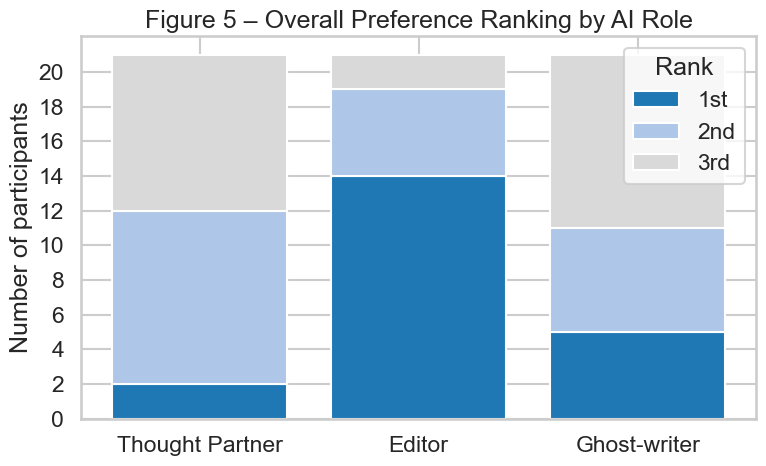

### Mean rank per condition (1 = most preferred)

,label,rank
0,Thought Partner,2.333
1,Editor,1.429
2,Ghost-writer,2.238


In [74]:
# ── Figure 5: Stacked bar chart of ranking frequencies ───────────────────────
# Colour intensity encodes rank (darkest = 1st choice).
rank_colors = {"1st": "#1f77b4", "2nd": "#aec7e8", "3rd": "#d9d9d9"}

fig5, ax5 = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(freq_table))
for rank_col, color in rank_colors.items():
    vals = freq_table[rank_col].values.astype(float) if rank_col in freq_table.columns else np.zeros(len(freq_table))
    ax5.bar(freq_table.index, vals, bottom=bottom, color=color, label=rank_col, edgecolor="white")
    bottom += vals

ax5.set_ylabel("Number of participants")
ax5.set_title("Figure 5 – Overall Preference Ranking by AI Role")
ax5.set_yticks(range(0, 22, 2))
ax5.legend(title="Rank", loc="upper right")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig5_preference_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Mean rank per condition (lower = more preferred) ─────────────────────────
mean_rank = (pref_long.groupby("condition", observed=True)["rank"]
                       .mean().reindex(CONDITION_ORDER)
                       .reset_index())
mean_rank["label"] = mean_rank["condition"].map(CONDITION_LABELS)
display(Markdown("### Mean rank per condition (1 = most preferred)"))
display(mean_rank[["label", "rank"]])

In [75]:
# ── Friedman test on ranks (non-parametric omnibus for ordinal ranking) ───────
# We treat each participant's 3 rank values as the repeated measure.
wide_rank = pref_long.pivot(index="participant_label", columns="condition", values="rank"
                            ).reindex(columns=CONDITION_ORDER).dropna()
chi2_rank, p_rank = stats.friedmanchisquare(*(wide_rank[c] for c in CONDITION_ORDER))
display(Markdown(f"**Friedman test on preference ranks:** χ²(2, N={len(wide_rank)}) = {chi2_rank:.2f}, p = {p_rank:.3f}"))

**Friedman test on preference ranks:** χ²(2, N=21) = 10.38, p = 0.006

---
## 10 – Behavioral Correlates of Authenticity

Spearman ρ between condition-specific process metrics and the SPMA composite.
These are exploratory and are not corrected for multiple comparisons.

In [76]:
# ── Subset each condition to only the rows where the metric is defined ────────
gw_df  = trial_df[trial_df["condition"] == "ghost_writer"].copy()
ed_df  = trial_df[trial_df["condition"] == "editor"].copy()
tp_df  = trial_df[trial_df["condition"] == "thought_partner"].copy()

# ── Compute all correlations ──────────────────────────────────────────────────
# Ghost-writer:
#   • ghost_revision_extent  – how much the participant rewrote the AI draft
#   • ghost_writer_edit_count – number of keystrokes made while editing the draft
# Editor:
#   • suggestion_acceptance_rate – fraction of AI suggestions accepted as-is
#   • suggestion_applied_rate    – fraction accepted + modified
#   • editor_revision_extent     – how different the final message is from the original
# Thought Partner:
#   • reflection_duration_sec    – time spent in reflection phase
#   • tp_reflection_word_count   – total words typed in reflection responses

corr_records = [
    spearman_corr(gw_df["ghost_revision_extent"],    gw_df["authenticity_composite"],  "GW – Revision extent"),
    spearman_corr(gw_df["ghost_writer_edit_count"],  gw_df["authenticity_composite"],  "GW – Edit keystrokes"),
    spearman_corr(ed_df["suggestion_acceptance_rate"],ed_df["authenticity_composite"], "ED – Suggestion acceptance rate"),
    spearman_corr(ed_df["suggestion_applied_rate"],  ed_df["authenticity_composite"],  "ED – Suggestion applied rate"),
    spearman_corr(ed_df["editor_revision_extent"],   ed_df["authenticity_composite"],  "ED – Revision extent"),
    spearman_corr(tp_df["reflection_duration_sec"],  tp_df["authenticity_composite"],  "TP – Reflection duration (sec)"),
    spearman_corr(tp_df["tp_reflection_word_count"], tp_df["authenticity_composite"],  "TP – Reflection word count"),
]

corr_df = pd.DataFrame(corr_records)
# Mark statistical significance at α = .05 and α = .01
corr_df["sig"] = corr_df["p"].apply(
    lambda p: "**" if p < .01 else ("*" if p < .05 else ("†" if p < .10 else "")))

display(Markdown("### Table 2 – Spearman correlations: process metrics vs. SPMA composite"))
display(corr_df[["metric", "n", "rho", "p", "sig"]])

### Table 2 – Spearman correlations: process metrics vs. SPMA composite

,metric,n,rho,p,sig
0,GW – Revision extent,21,0.608,0.003,**
1,GW – Edit keystrokes,21,0.678,0.001,**
2,ED – Suggestion acceptance rate,21,-0.372,0.097,†
3,ED – Suggestion applied rate,21,-0.358,0.111,
4,ED – Revision extent,21,-0.364,0.105,
5,TP – Reflection duration (sec),21,-0.535,0.013,*
6,TP – Reflection word count,21,-0.320,0.158,


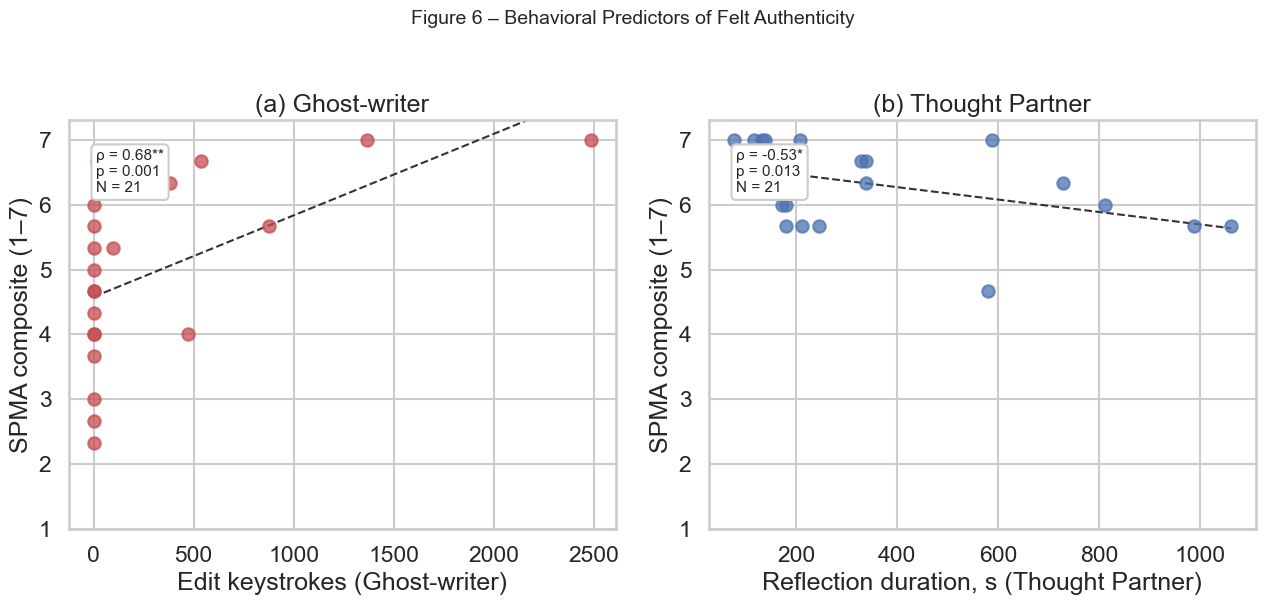

In [77]:
# ── Figure 6: Scatter panel – two key correlations from Table 2 ───────────────
# (a) Ghost-writer edit keystrokes vs. SPMA composite
# (b) Thought Partner reflection duration vs. SPMA composite

fig6, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, df_sub, xcol, xlab, cond_key, panel in [
    (axes[0], gw_df,  "ghost_writer_edit_count",  "Edit keystrokes (Ghost-writer)",    "ghost_writer",  "(a)"),
    (axes[1], tp_df,  "reflection_duration_sec",   "Reflection duration, s (Thought Partner)", "thought_partner", "(b)"),
]:
    # Drop rows where either variable is NaN
    plot_sub = df_sub[[xcol, "authenticity_composite"]].dropna()
    n_pts = len(plot_sub)

    # Scatter
    ax.scatter(plot_sub[xcol], plot_sub["authenticity_composite"],
               color=PALETTE[cond_key], s=80, alpha=0.75, zorder=3)

    # Linear trend line (for visual aid only — inference is Spearman)
    if n_pts >= 3:
        z = np.polyfit(plot_sub[xcol].astype(float), plot_sub["authenticity_composite"].astype(float), 1)
        x_line = np.linspace(plot_sub[xcol].min(), plot_sub[xcol].max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), color="#333333", lw=1.5, ls="--", zorder=2)

    # Annotate ρ and p
    rho_row = corr_df[corr_df["metric"].str.startswith("GW – Edit" if "edit" in xcol else "TP – Refl")]
    if not rho_row.empty:
        rho_val = rho_row.iloc[0]["rho"]
        p_val   = rho_row.iloc[0]["p"]
        sig_str = rho_row.iloc[0]["sig"]
        ax.text(0.05, 0.93, f"ρ = {rho_val:.2f}{sig_str}\np = {p_val:.3f}\nN = {n_pts}",
                transform=ax.transAxes, va="top", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc"))

    ax.set_xlabel(xlab)
    ax.set_ylabel("SPMA composite (1–7)")
    ax.set_title(f"{panel} {CONDITION_LABELS[cond_key]}")
    ax.set_ylim(1, 7.3)
    ax.set_yticks([1, 2, 3, 4, 5, 6, 7])

fig6.suptitle("Figure 6 – Behavioral Predictors of Felt Authenticity", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig6_behavioral_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 11 – Exploratory Item-Level Authenticity Breakdown

The three SPMA items are treated as distinct conceptual lenses:
- **genuine_thoughts_feelings** – awareness layer
- **authentic_voice** – expression layer
- **stand_behind_message** – global ownership

These are exploratory; Holm correction is applied across the six item-level contrasts.

In [78]:
# ── Per-item descriptives and RM ANOVA ───────────────────────────────────────
ITEM_META = [
    ("sender_authenticity_genuine_thoughts_feelings", "Genuine thoughts & feelings", "awareness"),
    ("sender_authenticity_authentic_voice",           "Authentic voice",             "expression"),
    ("sender_authenticity_stand_behind_message",      "Stand behind message",        "global ownership"),
]

all_contrast_ps  = []
all_contrast_rows = []

for item_col, item_label, layer in ITEM_META:
    display(Markdown(f"#### {item_label}  [{layer}]"))
    desc = descriptives_by_condition(trial_df, item_col)
    display(desc)

    # RM ANOVA
    anova_item = run_rm_anova(trial_df, item_col)
    display(anova_item)

    # Pre-planned contrasts (TP−GW, ED−GW) per item
    wide_item = trial_df.pivot(index="participant_label", columns="condition",
                                values=item_col).reindex(columns=CONDITION_ORDER)
    c1 = planned_contrast(wide_item["thought_partner"] - wide_item["ghost_writer"],
                           f"{item_label}: TP−GW")
    c2 = planned_contrast(wide_item["editor"]          - wide_item["ghost_writer"],
                           f"{item_label}: ED−GW")
    all_contrast_ps.extend([c1["p"], c2["p"]])
    all_contrast_rows.extend([c1, c2])

# ── Apply Holm and Bonferroni correction across all 6 item-level contrasts ──
_, p_adj_items, _, _ = multipletests(all_contrast_ps, method="holm")
_, p_adj_items_bonf, _, _ = multipletests(all_contrast_ps, method="bonferroni")
item_contrast_df = pd.DataFrame(all_contrast_rows)
item_contrast_df["p_holm"] = p_adj_items
item_contrast_df["p_bonferroni"] = p_adj_items_bonf

display(Markdown("### All item-level contrasts with Holm and Bonferroni correction"))
display(item_contrast_df[["contrast", "estimate", "ci_low", "ci_high", "t", "df", "p", "p_holm", "p_bonferroni", "cohens_dz"]])

#### Genuine thoughts & feelings  [awareness]

,condition,label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,21,6.238,0.831,6.000,4,7
1,editor,Editor,21,6.333,0.577,6.000,5,7
2,ghost_writer,Ghost-writer,21,5.571,1.287,6.000,3,7


,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,4.164,2.000,40.000,0.023,0.172


#### Authentic voice  [expression]

,condition,label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,21,6.286,0.784,6.000,5,7
1,editor,Editor,21,5.952,0.865,6.000,4,7
2,ghost_writer,Ghost-writer,21,4.571,1.805,4.000,2,7


...

#### Stand behind message  [global ownership]

,condition,label,n,mean,sd,median,min,max
0,thought_partner,Thought Partner,21,6.381,0.669,6.000,5,7
1,editor,Editor,21,6.095,0.995,6.000,3,7
2,ghost_writer,Ghost-writer,21,4.714,1.648,5.000,2,7


,effect,F,df_num,df_den,p_value,partial_eta_sq
0,condition,16.979,2.000,40.000,0.000,0.459


### All item-level contrasts with Holm and Bonferroni correction

,contrast,estimate,ci_low,ci_high,t,df,p,p_holm,p_bonferroni,cohens_dz
0,Genuine thoughts & feelings: TP−GW,0.667,-0.126,1.459,1.754,20,0.095,0.095,0.568,0.383
1,Genuine thoughts & feelings: ED−GW,0.762,0.245,1.279,3.074,20,0.006,0.012,0.036,0.671
2,Authentic voice: TP−GW,1.714,0.886,2.543,4.315,20,0.000,0.002,0.002,0.942
3,Authentic voice: ED−GW,1.381,0.626,2.135,3.818,20,0.001,0.004,0.006,0.833
4,Stand behind message: TP−GW,1.667,0.942,2.391,4.799,20,0.000,0.001,0.001,1.047
5,Stand behind message: ED−GW,1.381,0.599,2.162,3.686,20,0.001,0.004,0.009,0.804


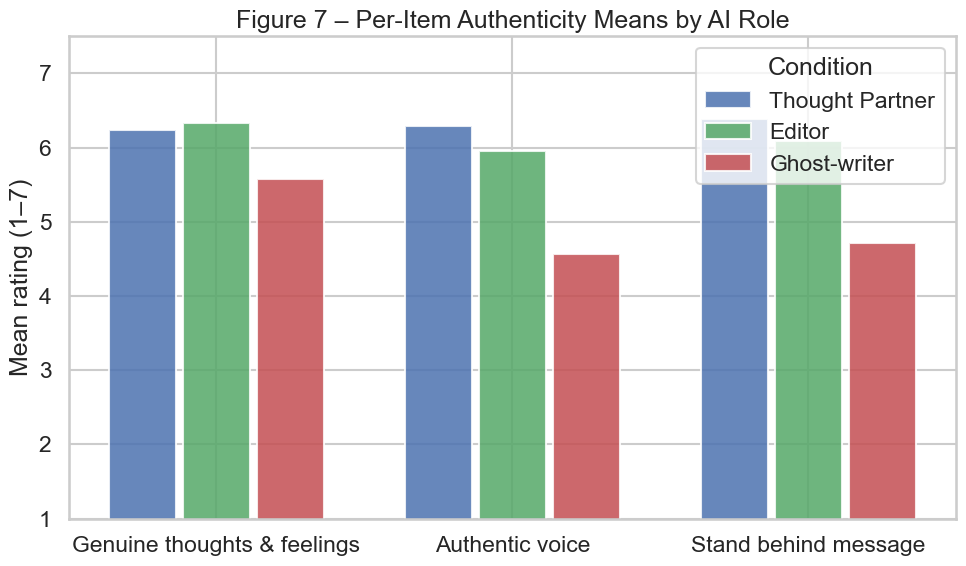

In [79]:
# ── Figure 7: Side-by-side bar chart of per-item means across conditions ──────
# This visually diagnoses whether Ghost-writer's deficit is expression-specific
# (authentic_voice) or global (all three items shift equally).

item_means = (trial_df.groupby("condition", observed=True)[[col for col, _, _ in ITEM_META]]
                       .mean().reindex(CONDITION_ORDER))
item_means.index = [CONDITION_LABELS[c] for c in CONDITION_ORDER]
item_means.columns = [lbl for _, lbl, _ in ITEM_META]

fig7, ax7 = plt.subplots(figsize=(10, 6))
x7 = np.arange(len(ITEM_META))
w  = 0.25
offsets = [-w, 0, w]
for i, (cond_label, color) in enumerate(zip([CONDITION_LABELS[c] for c in CONDITION_ORDER],
                                             PALETTE.values())):
    ax7.bar(x7 + offsets[i], item_means.loc[cond_label], width=w * 0.9,
            color=color, label=cond_label, alpha=0.85, edgecolor="white")

ax7.set_xticks(x7)
ax7.set_xticklabels([lbl for _, lbl, _ in ITEM_META])
ax7.set_ylabel("Mean rating (1–7)")
ax7.set_ylim(1, 7.5)
ax7.set_yticks([1, 2, 3, 4, 5, 6, 7])
ax7.legend(title="Condition")
ax7.set_title("Figure 7 – Per-Item Authenticity Means by AI Role")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig7_item_means_bar.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12 – Multi-panel summary figure

A single 2×2 figure combining the four primary outcomes for use in the paper.

/var/folders/8y/9zl8wzs515d1f09vnl7m05vm0000gr/T/ipykernel_97574/1559995647.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data_p, x="label", y=dv, order=order_lbls,


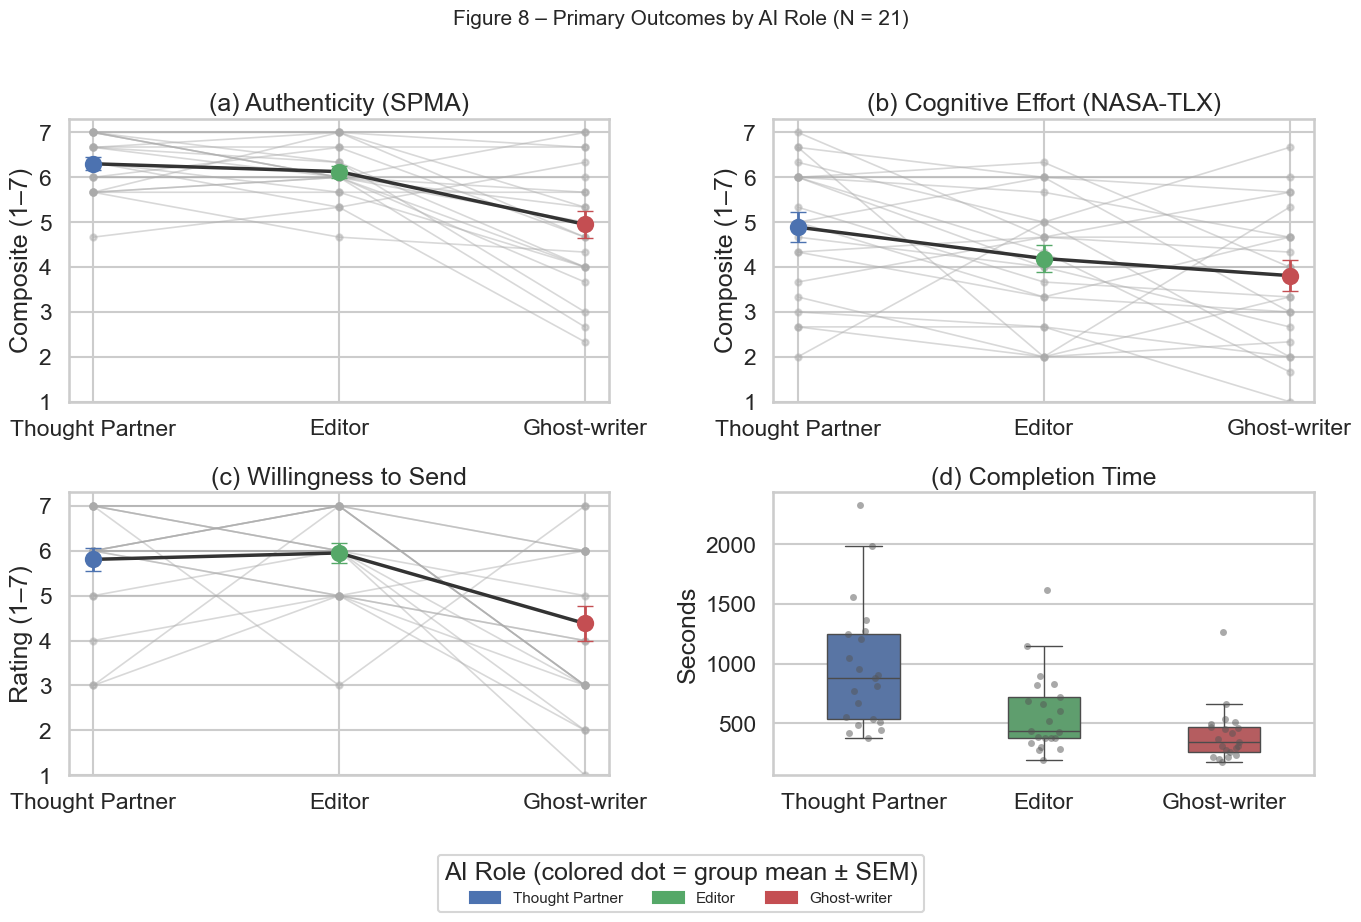

In [80]:
# ── Figure 8: 2×2 summary panel ──────────────────────────────────────────────
# Panel layout:
#   [0,0] Authenticity composite    [0,1] Effort composite
#   [1,0] Willingness to send       [1,1] Log completion time (back-transformed)

fig8, axes8 = plt.subplots(2, 2, figsize=(14, 10))

panel_specs = [
    (axes8[0, 0], "authenticity_composite",       "(a) Authenticity (SPMA)",     "Composite (1–7)",  (1, 7.3), [1,2,3,4,5,6,7]),
    (axes8[0, 1], "effort_composite",             "(b) Cognitive Effort (NASA-TLX)", "Composite (1–7)", (1, 7.3), [1,2,3,4,5,6,7]),
    (axes8[1, 0], "satisfaction_willing_to_send", "(c) Willingness to Send",     "Rating (1–7)",     (1, 7.3), [1,2,3,4,5,6,7]),
    (axes8[1, 1], "completion_time_sec",          "(d) Completion Time",         "Seconds",          None, None),
]

for ax, dv, title, ylabel, ylim, yticks in panel_specs:
    if dv == "completion_time_sec":
        # Box + strip for time (not spaghetti) because scale is different
        plot_data_p = trial_df[["condition", dv]].copy()
        plot_data_p["label"] = plot_data_p["condition"].map(CONDITION_LABELS)
        order_lbls = [CONDITION_LABELS[c] for c in CONDITION_ORDER]
        sns.boxplot(data=plot_data_p, x="label", y=dv, order=order_lbls,
                    palette=list(PALETTE.values()), width=0.4, fliersize=0, ax=ax)
        sns.stripplot(data=plot_data_p, x="label", y=dv, order=order_lbls,
                      color="#555555", alpha=0.5, size=5, jitter=True, ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
    else:
        spaghetti_plot(trial_df, dv, title=title, ylabel=ylabel,
                       ylim=ylim, yticks=yticks, ax=ax)

# Shared legend for the colored dots
handles = [mpatches.Patch(color=PALETTE[c], label=CONDITION_LABELS[c]) for c in CONDITION_ORDER]
fig8.legend(handles=handles, loc="lower center", ncol=3, fontsize=11,
            title="AI Role (colored dot = group mean ± SEM)", frameon=True, bbox_to_anchor=(0.5, 0.1))

fig8.suptitle(f"Figure 8 – Primary Outcomes by AI Role (N = {N_PARTICIPANTS})", fontsize=15, y=1.01)
plt.tight_layout(rect=(0, 0.18, 1, 1))
plt.savefig(DATA_DIR / "fig8_summary_panel.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 13 – Global Correction Across All Main Pairwise Contrasts

This sensitivity table treats the 3 pairwise contrasts for each of the 4 primary outcomes as one family of 12 tests. This is more conservative than correcting within each RQ/outcome family.

In [81]:
# ── Global correction across all 12 main-outcome pairwise contrasts ─────────
# This is a conservative sensitivity analysis: 4 outcomes x 3 condition pairs.
# The time outcome uses log(completion time), matching the primary ANOVA.

MAIN_PAIRWISE_OUTCOMES = [
    ("Authenticity composite", "authenticity_composite"),
    ("Cognitive effort composite", "effort_composite"),
    ("Willingness to send", "satisfaction_willing_to_send"),
    ("Log completion time", "log_completion_time"),
]

MAIN_PAIRWISE_PAIRS = [
    ("thought_partner", "editor"),
    ("thought_partner", "ghost_writer"),
    ("editor", "ghost_writer"),
]

main_pairwise_rows = []
for outcome_label, dv in MAIN_PAIRWISE_OUTCOMES:
    wide = trial_df.pivot(index="participant_label", columns="condition", values=dv).reindex(columns=CONDITION_ORDER)
    for cond_a, cond_b in MAIN_PAIRWISE_PAIRS:
        row = planned_contrast(
            wide[cond_a] - wide[cond_b],
            f"{CONDITION_LABELS[cond_a]} - {CONDITION_LABELS[cond_b]}",
        )
        row["outcome"] = outcome_label
        row["condition_a"] = cond_a
        row["condition_b"] = cond_b
        main_pairwise_rows.append(row)

main_pairwise_global = pd.DataFrame(main_pairwise_rows)
_, p_holm_global, _, _ = multipletests(main_pairwise_global["p"].values, method="holm")
_, p_bonf_global, _, _ = multipletests(main_pairwise_global["p"].values, method="bonferroni")
main_pairwise_global["p_holm_global_12"] = p_holm_global
main_pairwise_global["p_bonferroni_global_12"] = p_bonf_global

display(Markdown("### Main outcome pairwise contrasts with global correction across 12 tests"))
display(main_pairwise_global[[
    "outcome", "contrast", "estimate", "ci_low", "ci_high", "t", "df", "p",
    "p_holm_global_12", "p_bonferroni_global_12", "cohens_dz",
]])

### Main outcome pairwise contrasts with global correction across 12 tests

,outcome,contrast,estimate,ci_low,ci_high,t,df,p,p_holm_global_12,p_bonferroni_global_12,cohens_dz
0,Authenticity composite,Thought Partner - Editor,0.175,-0.127,0.477,1.206,20,0.242,0.726,1.000,0.263
1,Authenticity composite,Thought Partner - Ghost-writer,1.349,0.635,2.063,3.941,20,0.001,0.007,0.010,0.860
2,Authenticity composite,Editor - Ghost-writer,1.175,0.565,1.785,4.017,20,0.001,0.007,0.008,0.877
3,Cognitive effort composite,Thought Partner - Editor,0.698,0.003,1.394,2.096,20,0.049,0.196,0.588,0.457
4,Cognitive effort composite,Thought Partner - Ghost-writer,1.079,0.514,1.645,3.981,20,0.001,0.007,0.009,0.869
5,Cognitive effort composite,Editor - Ghost-writer,0.381,-0.357,1.119,1.077,20,0.294,0.726,1.000,0.235
6,Willingness to send,Thought Partner - Editor,-0.143,-0.837,0.552,-0.429,20,0.673,0.726,1.000,-0.094
7,Willingness to send,Thought Partner - Ghost-writer,1.429,0.436,2.421,3.002,20,0.007,0.042,0.085,0.655
8,Willingness to send,Editor - Ghost-writer,1.571,0.568,2.575,3.267,20,0.004,0.027,0.046,0.713
9,Log completion time,Thought Partner - Editor,0.513,0.304,0.722,5.124,20,0.000,0.001,0.001,1.118


---
## 14 – Export results to CSV

Saves all key statistics tables so they can be referenced when filling in the paper's TO-BE-POPULATED sections.

In [82]:
# ── Write key result tables to disk ──────────────────────────────────────────
OUT = DATA_DIR / "results_tables"
OUT.mkdir(exist_ok=True)

auth_desc.to_csv(OUT / "rq1_auth_descriptives.csv", index=False)
anova_auth.to_csv(OUT / "rq1_auth_anova.csv", index=False)
contrasts_auth.to_csv(OUT / "rq1_auth_contrasts.csv", index=False)

effort_desc.to_csv(OUT / "rq2_effort_descriptives.csv", index=False)
anova_effort.to_csv(OUT / "rq2_effort_anova.csv", index=False)
contrasts_eff.to_csv(OUT / "rq2_effort_contrasts.csv", index=False)

wts_desc.to_csv(OUT / "rq3a_wts_descriptives.csv", index=False)
anova_wts.to_csv(OUT / "rq3a_wts_anova.csv", index=False)

time_desc.to_csv(OUT / "rq3b_time_descriptives.csv", index=False)
anova_time.to_csv(OUT / "rq3b_time_anova.csv", index=False)
main_pairwise_global.to_csv(OUT / "main_outcome_pairwise_global_correction.csv", index=False)

freq_table.to_csv(OUT / "rq3c_preference_freq.csv")

corr_df.to_csv(OUT / "behavioral_correlates.csv", index=False)
item_contrast_df.to_csv(OUT / "item_level_contrasts.csv", index=False)

reliability_df.to_csv(OUT / "reliability.csv", index=False)

print(f"Tables saved to {OUT.resolve()}")

Tables saved to /Users/kevin/school/544-hci/544-project/result_analysis/results_tables
